# Multimodal approach using both RAW EEG Features & Spectrograms


#### Overall pipeline in this notebook is somewhat like this.
![img2](https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F4712534%2Fc4e39641fa8ec13588b62065ae1e9b58%2FScreenshot%202024-02-10%20at%2010.40.36%20PM.png?generation=1707585942607444&alt=media)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from sklearn import model_selection
import torchvision.transforms as transforms
import torchvision.io 
import librosa
from PIL import Image
import albumentations as alb
import torch.multiprocessing as mp
import warnings
import os
from pytorch_lightning.callbacks import ModelCheckpoint, BackboneFinetuning, EarlyStopping

warnings.filterwarnings('ignore')


### Kindly update the paths in the following config to run the same model on Kaggle notebooks. You can import other datasets from Moth's notebook, I have shared above.

In [2]:
class Config:
    use_aug = False
    num_classes = 6
    batch_size = 32
    epochs = 10
    PRECISION = 16
    PATIENCE = 20    
    seed = 42
    backbone_2d = 'tf_efficientnet_b0'
    pretrained = True            
    weight_decay = 1e-2
    use_mixup = False
    mixup_alpha = 0.1   
    num_channels = 8
    data_root = "/kaggle/input/hba-sampled-data/"
    PRE_LOADED_EEGS = "/kaggle/input/hba-sampled-data/eegs.npy"
    PRE_LOADED_SPECTOGRAMS = "/kaggle/input/hba-sampled-data/eeg_spectrograms.npy"
    TRAIN_EEGS = "/kaggle/input/hms-harmful-brain-activity-classification/train_eegs"
    LR = 7e-4
    processed_train = None
    output_dir = '/kaggle/output/'
    trn_folds = [0,1,2,3,4]

In [3]:
if not os.path.exists(Config.output_dir):
    os.makedirs(Config.output_dir)

In [4]:
pl.seed_everything(Config.seed, workers=True)

42

In [5]:
def config_to_dict(cfg):
    return dict((name, getattr(cfg, name)) for name in dir(cfg) if not name.startswith('__'))

In [6]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt

# df = pd.read_csv(f'{Config.data_root}train.csv')
df = pd.read_csv(f'{Config.data_root}train_300_patients.csv')
print( df.shape )


(15462, 16)


#### Drop duplicates

In [7]:
EEG_IDS = df.eeg_id.unique()

TARGETS = df.columns[-6:]
TARS = {'Seizure':0, 'LPD':1, 'GPD':2, 'LRDA':3, 'GRDA':4, 'Other':5}
TARS_INV = {x:y for y,x in TARS.items()}

train_df = df.groupby('eeg_id')[['spectrogram_id','spectrogram_label_offset_seconds']].agg({
    'spectrogram_id':'first',
    'spectrogram_label_offset_seconds':'min'
})
train_df.columns = ['spectogram_id','min']

aux = df.groupby('eeg_id')[['spectrogram_id','spectrogram_label_offset_seconds']].agg({
    'spectrogram_label_offset_seconds':'max'
})
train_df['max'] = aux

aux = df.groupby('eeg_id')[['patient_id']].agg('first')
train_df['patient_id'] = aux

aux = df.groupby('eeg_id')[TARGETS].agg('sum')
for label in TARGETS:
    train_df[label] = aux[label].values
    
y_data = train_df[TARGETS].values
y_data = y_data / y_data.sum(axis=1,keepdims=True)
train_df[TARGETS] = y_data

aux = df.groupby('eeg_id')[['expert_consensus']].agg('first')
train_df['target'] = aux

train = train_df.reset_index()
print('Train non-overlapp eeg_id shape:', train_df.shape )
train.head()


Train non-overlapp eeg_id shape: (2500, 11)


,eeg_id,spectogram_id,min,max,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,target
0,3907459,1343094925,3688.0,3694.0,6489,0.000000,0.0,0.0,0.666667,0.0,0.333333,LRDA
1,4969792,1683476984,0.0,2.0,19311,0.066667,0.8,0.0,0.000000,0.0,0.133333,LPD
2,5586700,619167662,270.0,270.0,20547,0.000000,0.0,0.0,0.000000,0.0,1.000000,Other
3,6259482,1497099492,0.0,62.0,2659,0.000000,0.0,0.0,0.000000,1.0,0.000000,GRDA
4,9418744,581115791,0.0,0.0,18815,0.000000,0.0,0.0,0.000000,0.0,1.000000,Other


In [8]:
Config.num_classes = len(TARS.keys())

In [9]:
train.describe()

,eeg_id,spectogram_id,min,max,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
count,2.500000e+03,2.500000e+03,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2.127418e+09,1.111221e+09,471.230400,500.887200,34259.215600,0.164182,0.116692,0.131855,0.055327,0.127192,0.404752
std,1.235189e+09,6.332770e+08,1281.347882,1286.240631,19854.510854,0.331467,0.268086,0.286598,0.168023,0.278381,0.403680
min,3.907459e+06,4.934635e+06,0.000000,0.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.068440e+09,5.696874e+08,0.000000,4.000000,18186.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.090837e+09,1.105876e+09,0.000000,40.000000,36197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.307692
75%,3.192565e+09,1.677354e+09,344.000000,382.500000,55111.000000,0.066667,0.000000,0.000000,0.000000,0.066667,0.846154
max,4.294455e+09,2.145732e+09,10884.000000,10884.000000,65264.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
def eeg_from_parquet(parquet_path, display=False):
    
    # EXTRACT MIDDLE 50 SECONDS
    eeg = pd.read_parquet(parquet_path, columns=FEATS)
    rows = len(eeg)
    offset = (rows-10_000)//2
    eeg = eeg.iloc[offset:offset+10_000]
    
    if display: 
        plt.figure(figsize=(10,5))
        offset = 0
    
    # CONVERT TO NUMPY
    data = np.zeros((10_000,len(FEATS)))
    for j,col in enumerate(FEATS):
        
        # FILL NAN
        x = eeg[col].values.astype('float32')
        m = np.nanmean(x)
        if np.isnan(x).mean()<1: x = np.nan_to_num(x,nan=m)
        else: x[:] = 0
            
        data[:,j] = x
        
        if display: 
            if j!=0: offset += x.max()
            plt.plot(range(10_000),x-offset,label=col)
            offset -= x.min()
            
    if display:
        plt.legend()
        name = parquet_path.split('/')[-1]
        name = name.split('.')[0]
        plt.title(f'EEG {name}',size=16)
        plt.show()
        
    return data

In [11]:
%%time
all_spectrograms = np.load(Config.PRE_LOADED_SPECTOGRAMS, allow_pickle=True).item()

CPU times: user 729 ms, sys: 1.22 s, total: 1.95 s
Wall time: 13.1 s


In [12]:
%%time
all_eegs = np.load(Config.PRE_LOADED_EEGS, allow_pickle=True).item()


CPU times: user 844 ms, sys: 1.46 s, total: 2.3 s
Wall time: 14.8 s


In [13]:
all_eegs[train.loc[0,'eeg_id']].shape

(10000, 8)

In [14]:
all_spectrograms[train.loc[0,'eeg_id']].shape

(128, 256, 4)

### Build up the EEGWaveNet and EEGSpecNet model

In [15]:
import torch
import torch.nn as nn


class ResNet_1D_Block(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, downsampling):
        super(ResNet_1D_Block, self).__init__()
        self.bn1 = nn.BatchNorm1d(num_features=in_channels)
        self.relu = nn.ReLU(inplace=False)
        self.dropout = nn.Dropout(p=0.1, inplace=False)
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(num_features=out_channels)
        self.conv2 = nn.Conv1d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        self.downsampling = downsampling

    def forward(self, x):
        identity = x

        out = self.bn1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)

        out = self.maxpool(out)
        identity = self.downsampling(x)

        out += identity
        return out

In [16]:
class EEGWaveNet(nn.Module):
    def __init__(self, kernels, in_channels=20, fixed_kernel_size=17, num_classes=6):
        super(EEGWaveNet, self).__init__()
        self.kernels = kernels
        self.num_classes = num_classes
        self.planes = 24
        self.parallel_conv = nn.ModuleList()
        self.in_channels = in_channels
        for i, kernel_size in enumerate(list(self.kernels)):
            sep_conv = nn.Conv1d(in_channels=in_channels, out_channels=self.planes, kernel_size=(kernel_size),
                               stride=1, padding=0, bias=False,)
            self.parallel_conv.append(sep_conv)
        self.bn1 = nn.BatchNorm1d(num_features=self.planes)
        self.relu = nn.ReLU(inplace=False)
        self.conv1 = nn.Conv1d(in_channels=self.planes, out_channels=self.planes, kernel_size=fixed_kernel_size,
                               stride=2, padding=2, bias=False)
        self.block = self._make_resnet_layer(kernel_size=fixed_kernel_size, stride=1, padding=fixed_kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_features=self.planes)
        self.avgpool = nn.AvgPool1d(kernel_size=4, stride=4, padding=2)
        self.rnn = nn.GRU(input_size=self.in_channels, hidden_size=128, num_layers=1, bidirectional=True)
        self.fc1 = nn.Linear(in_features=736, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
    
    def _make_resnet_layer(self, kernel_size, stride, blocks=8, padding=0):
        layers = []
        downsample = None
        base_width = self.planes

        for i in range(blocks):
            downsampling = nn.Sequential(
                    nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
                )
            layers.append(ResNet_1D_Block(in_channels=self.planes, out_channels=self.planes, kernel_size=kernel_size,
                                       stride=stride, padding=padding, downsampling=downsampling))

        return nn.Sequential(*layers)

    def forward(self, x):
        out_sep = []
        for i in range(len(self.kernels)):
            sep = self.parallel_conv[i](x)
            out_sep.append(sep)

        out = torch.cat(out_sep, dim=2)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv1(out)  

        out = self.block(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.avgpool(out)

        out = out.reshape(out.shape[0], -1)  

        rnn_out, _ = self.rnn(x.permute(0, 2, 1))
        new_rnn_h = rnn_out[:, -1, :]  
        
        new_out = torch.cat([out, new_rnn_h], dim=1)  
        feats = self.fc1(new_out)
        logits = self.fc2(feats)
        return feats, logits


class EEGSpecNet(nn.Module):
    def __init__(self, in_channels_2d, backbone_2d=Config.backbone_2d, pretrained=False, num_classes=6):
        super(EEGSpecNet, self).__init__()
        self.backbone_2d = timm.create_model(
            backbone_2d,
            pretrained=pretrained,
            drop_rate = 0.1,
            drop_path_rate = 0.1
        )
        
        self.features_2d = nn.Sequential(*list(self.backbone_2d.children())[:-2] + [nn.AdaptiveAvgPool2d(1),nn.Flatten()])
        self.fc1 = nn.Linear(in_features=1280, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
    
    def _reshape_input(self, spec):
        """
        Reshapes input (128, 256, 4) -> (512, 512, 3) monotone image.
        """ 
        # === Get spectograms ===
        spec = torch.permute(spec, (0, 1, 3, 2)).flatten(1, 2)
        spec = torch.cat([spec, spec], axis=-1)
        # LL, LP, RP, RL
        spec = torch.stack([spec,spec,spec], dim=3)
        spec = spec.permute(0, 3, 1, 2)
        return spec
    
    def forward(self, spec):
        spec = self._reshape_input(spec)
        spec = self.features_2d(spec)
        feats = self.fc1(spec)  
        logits = self.fc2(feats)
        return feats, logits

In [17]:
from scipy.signal import butter, lfilter

def quantize_data(data, classes):
    mu_x = mu_law_encoding(data, classes)
    # bins = np.linspace(-1, 1, classes)
    # quantized = np.digitize(mu_x, bins) - 1
    return mu_x#quantized

def mu_law_encoding(data, mu):
    mu_x = np.sign(data) * np.log(1 + mu * np.abs(data)) / np.log(mu + 1)
    return mu_x

def mu_law_expansion(data, mu):
    s = np.sign(data) * (np.exp(np.abs(data) * np.log(mu + 1)) - 1) / mu
    return s

def butter_lowpass_filter(data, cutoff_freq=20, sampling_rate=200, order=4):
    nyquist = 0.5 * sampling_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = lfilter(b, a, data, axis=0)
    return filtered_data


In [18]:
import torch
import numpy as np
import pandas as pd
from scipy.signal import butter, lfilter

class EEGDataset(torch.utils.data.Dataset):
    def __init__(self, data, eegs=None, eeg_specs=None, test=False): 
        self.data = data
        self.eegs = eegs
        self.eeg_specs = eeg_specs  # EEG spectrograms for each ID
        self.test = test
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        row = self.data.iloc[index]
        
        # Processing EEG signal data
        eeg_data = self.eegs[row.eeg_id]
        sample = np.zeros((eeg_data.shape[0], 8))  # Assuming eeg_data.shape[1] == 8 for 8 channels
        FEAT2IDX = {'Fp1': 0, 'T3': 1, 'C3': 2, 'O1': 3, 'Fp2': 4, 'C4': 5, 'T4': 6, 'O2': 7}
        
        # Compute differences
        for i, (start, end) in enumerate([('Fp1', 'T3'), ('T3', 'O1'), ('Fp1', 'C3'), ('C3', 'O1'), 
                                          ('Fp2', 'C4'), ('C4', 'O2'), ('Fp2', 'T4'), ('T4', 'O2')]):
            sample[:, i] = eeg_data[:, FEAT2IDX[start]] - eeg_data[:, FEAT2IDX[end]]
        
        sample = self.process_sample(sample)
        
        samples = torch.from_numpy(sample).float()
        samples = samples.permute(1, 0)
        
        # Processing spectrogram data
        spec = self.__spec_data_generation(row)
        if not self.test:
            label = row[TARGETS]  # Assuming 'TARGETS' is defined somewhere as the label column name
            label = torch.tensor(label).float()  
            return samples, spec, label
        else:
            return samples, spec
    
    def process_sample(self, sample):
        # Normalize the sample data
        sample = (sample - np.mean(sample, axis=0)) / np.std(sample, axis=0)
        sample = np.clip(sample, -1024, 1024)
        sample = np.nan_to_num(sample, nan=0)
        sample = butter_lowpass_filter(sample)
        sample = quantize_data(sample, 1)
        return sample

    def __spec_data_generation(self, row):
        """
        Generates data containing batch_size samples. This method directly
        uses class attributes for spectrograms and EEG spectrograms.
        """
        img = self.eeg_specs[row.eeg_id]             
        return img


In [19]:
from sklearn.model_selection import *

gkf = GroupKFold(n_splits=5)
train['fold'] = 0
for fold, (tr_idx, val_idx) in enumerate(gkf.split(train, train.target, train.patient_id)):   
    train.loc[val_idx, 'fold'] = fold


In [20]:
def get_fold_dls(df_train, df_valid):
    ds_train = EEGDataset(
        df_train, 
        eegs=all_eegs,
        eeg_specs=all_spectrograms,
        test = False
    )
    
    ds_val = EEGDataset(
        df_valid, 
        eegs=all_eegs,
        eeg_specs=all_spectrograms,
        test = False
    )
    dl_train = DataLoader(ds_train, batch_size=Config.batch_size , shuffle=True, num_workers = 2)    
    dl_val = DataLoader(ds_val, batch_size=Config.batch_size, num_workers = 2)
    return dl_train, dl_val, ds_train, ds_val

In [21]:
def show_batch(img_ds, num_items, num_rows, num_cols, EEG_IDS, predict_arr=None):
    fig = plt.figure(figsize=(12, 6))    
    img_index = np.random.randint(0, len(img_ds)-1, num_items)
    for index, img_index in enumerate(img_index):  # list first items
        img,spec, lb = img_ds[img_index]    
        print(spec.shape)
        ax = fig.add_subplot(num_rows, num_cols, index + 1, xticks=[], yticks=[])
        if isinstance(img, torch.Tensor):
            img = img.detach().numpy()
            img = img.transpose(1,0)
            # print(img.shape)
        offset = 0
        for j in range(img.shape[-1]):
            if j != 0: offset -= img[:, j].min()
            ax.plot(img[:, j] + offset, label=f'feature {j+1}')
            offset += img[:, j].max() + 1  # Adding 1 for visual separation

        ax.legend()
        ax.set_title(f'EEG_Id = {EEG_IDS[img_index]}', size=14)

    plt.tight_layout()
    plt.show()

In [22]:
dummy_train = train[train['fold']!=0].copy()
dummy_valid = train[train['fold']==0].copy()


(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)


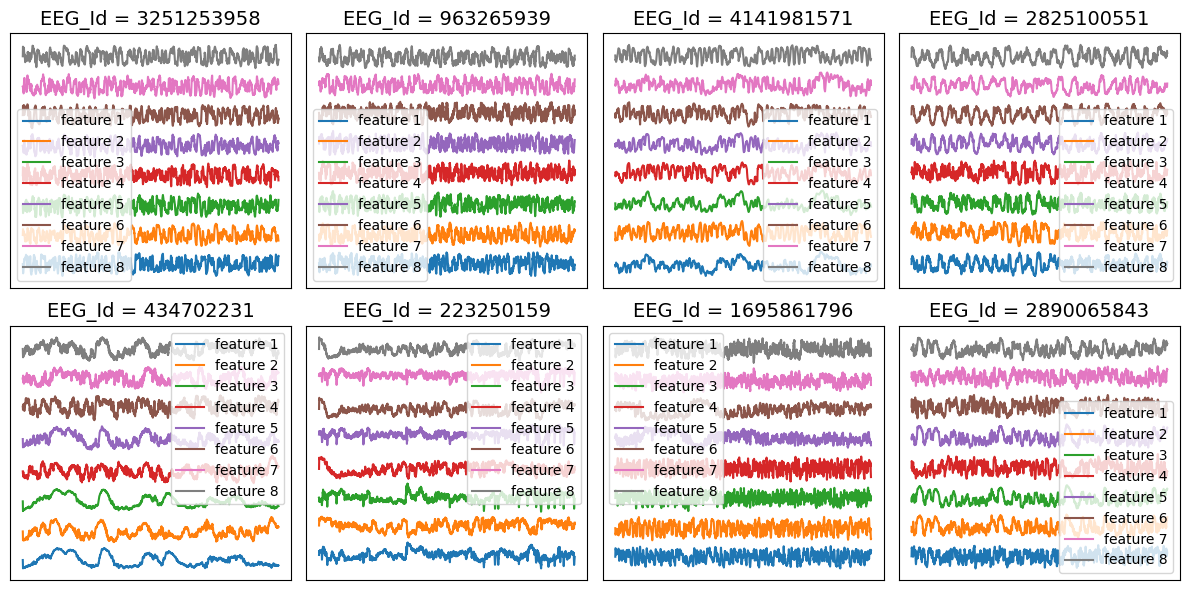

CPU times: user 4.31 s, sys: 18.3 ms, total: 4.33 s
Wall time: 4.25 s


In [23]:
%%time
dl_train, dl_val, ds_train, ds_val = get_fold_dls(dummy_train, dummy_valid)
show_batch(ds_val, 8, 2, 4, EEG_IDS)

(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)
(128, 256, 4)


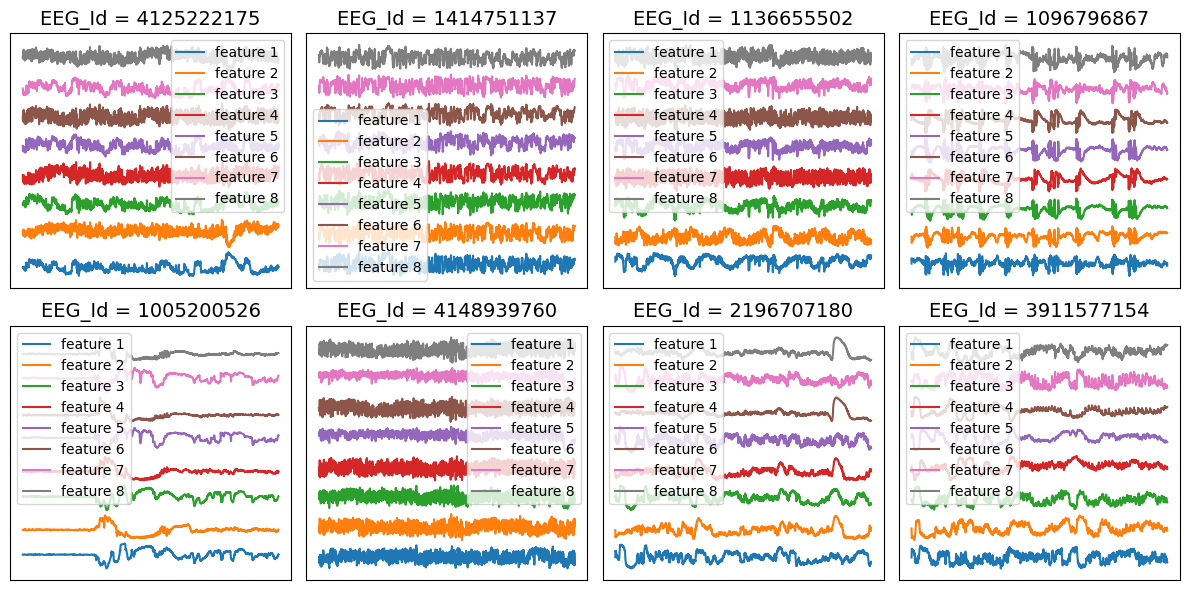

CPU times: user 3.99 s, sys: 21.1 ms, total: 4.01 s
Wall time: 3.89 s


In [24]:
%%time
dl_train, dl_val, ds_train, ds_val = get_fold_dls(dummy_train, dummy_valid)
show_batch(ds_train, 8, 2, 4, EEG_IDS)

In [25]:
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts, ReduceLROnPlateau, OneCycleLR

def get_optimizer(lr, params):
    model_optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, params), 
            lr=lr,
            weight_decay=Config.weight_decay
        )
    interval = "epoch"
    
    lr_scheduler = CosineAnnealingWarmRestarts(
                            model_optimizer, 
                            T_0=Config.epochs, 
                            T_mult=1, 
                            eta_min=1e-7, 
                            last_epoch=-1
                        )

    return {
        "optimizer": model_optimizer, 
        "lr_scheduler": {
            "scheduler": lr_scheduler,
            "interval": interval,
            "monitor": "val_loss",
            "frequency": 1
        }
    }

In [26]:
!pip install pytorchtools

In [27]:
# from torchtoolbox.tools import mixup_data, mixup_criterion
import torch.nn as nn
from torch.nn.functional import cross_entropy
import torchmetrics
import timm

In [28]:
import sklearn.metrics
import sys
sys.path.append('/kaggle/input/kaggle-kl-div')

from kaggle_kl_div import score


In [29]:
class KLDivLossWithLogits(nn.KLDivLoss):

    def __init__(self):
        super().__init__(reduction="batchmean")

    def forward(self, y, t):
        y = nn.functional.log_softmax(y,  dim=1)
        loss = super().forward(y, t)

        return loss


#### Combined Models?

In [30]:
class EEGMegaNet(nn.Module):
    def __init__(self, in_channels_2d, kernels, backbone_2d=Config.backbone_2d, pretrained=False, in_channels=Config.num_channels, fixed_kernel_size=17, num_classes=6):
        super(EEGMegaNet, self).__init__()
        self.eeg_spec_net = EEGSpecNet(in_channels_2d, backbone_2d, pretrained, num_classes)
        self.eeg_wavenet = EEGWaveNet(kernels, in_channels=8, fixed_kernel_size=fixed_kernel_size, num_classes=num_classes)
        self.fc = nn.Linear(in_features=256, out_features=num_classes)
    
    def forward(self, eeg, spec):
        eeg_feats, eeg_logits = self.eeg_wavenet(eeg)
        spec_feats, spec_logits = self.eeg_spec_net(spec)
        feats = torch.cat([eeg_feats, spec_feats], dim=1)
        logits = self.fc(feats)
        return logits, eeg_feats, spec_feats, eeg_logits, spec_logits
    
    @property
    def linear_layers(self):
        return [self.eeg_spec_net.fc1, self.eeg_spec_net.fc2, self.eeg_wavenet.fc1, self.eeg_wavenet.fc2, self.fc]

In [31]:
class EEGModel(pl.LightningModule):
    def __init__(self, fold, num_classes = Config.num_classes, pretrained = Config.pretrained):
        super().__init__()
        self.num_classes = num_classes
        self.fold = fold
        self.backbone = EEGMegaNet(backbone_2d=Config.backbone_2d,
                                   in_channels_2d=8,
                                   kernels=[5,7,9,11],pretrained=True,
                                   in_channels=Config.num_channels,
                                   fixed_kernel_size=5, num_classes=6)
        self.contrastive_loss = nn.CosineEmbeddingLoss()  # Using cosine similarity for contrastive loss

        self.loss_function = KLDivLossWithLogits() #nn.KLDivLoss() #nn.BCEWithLogitsLoss() 
        self.validation_step_outputs = []
        self.lin = nn.Softmax(dim=1)
        self.best_score = 1000.0
        self.linear_init(self.backbone.linear_layers)
    
    def linear_init(self, layers):
        for layer in layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self,eeg, spec):
        logits = self.backbone(eeg, spec)
        # logits = self.lin(logits)
        return logits
        
    def configure_optimizers(self):
        return get_optimizer(lr=Config.LR, params=self.parameters())

    def training_step(self, batch, batch_idx):
        eeg, spec, target = batch
        y_pred, embedding_1d, embedding_2d, yp1, yp2 = self(eeg, spec)
        classification_loss = self.loss_function(y_pred, target)
        
        classification_loss1 = self.loss_function(yp1, target)
        classification_loss2 = self.loss_function(yp2, target)
        

        # Calculate contrastive loss 
        
        embedding_1d = torch.nn.functional.normalize(embedding_1d, p=2, dim=1)
        embedding_2d = torch.nn.functional.normalize(embedding_2d, p=2, dim=1)

        
        contrastive_target = torch.ones(embedding_1d.size(0)).to(self.device)  # Assuming all pairs are similar
        contrastive_loss = self.contrastive_loss(embedding_1d, embedding_2d, contrastive_target)

        total_loss = classification_loss + classification_loss1*0.5 + classification_loss2*0.5 + contrastive_loss*0.5  # Aux losses

        self.log("train_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True)
        return total_loss     

    def validation_step(self, batch, batch_idx):
        eeg, spec, target = batch 
        # print(target)
        y_pred,_,_,y1d,y2d = self(eeg, spec)

        y_pred = y_pred*0.5 + y1d*0.25 + y2d*0.25
        val_loss = self.loss_function(y_pred, target)
        self.log("val_loss", val_loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.validation_step_outputs.append({"val_loss": val_loss, "logits": y_pred, "targets": target})

        return {"val_loss": val_loss, "logits": y_pred, "targets": target}
    
    def train_dataloader(self):
        return self._train_dataloader 
    
    def validation_dataloader(self):
        return self._validation_dataloader
    
    def on_validation_epoch_end(self):
        outputs = self.validation_step_outputs
        # print(len(outputs))
        avg_loss = torch.stack([x['val_loss'] for x in outputs]).mean()
        output_val = nn.Softmax(dim=1)(torch.cat([x['logits'] for x in outputs],dim=0)).cpu().detach().numpy()
        target_val = torch.cat([x['targets'] for x in outputs],dim=0).cpu().detach().numpy()
        self.validation_step_outputs = []

        val_df = pd.DataFrame(target_val, columns = list(TARGETS))
        pred_df = pd.DataFrame(output_val, columns = list(TARGETS))

        val_df['id'] = [f'id_{i}' for i in range(len(val_df))] 
        pred_df['id'] = [f'id_{i}' for i in range(len(pred_df))] 

        avg_score = avg_loss
        # avg_score = score(val_df, pred_df, row_id_column_name = 'id')

        if avg_score < self.best_score:
            print(f'Fold {self.fold}: Epoch {self.current_epoch} validation loss {avg_loss}')
            print(f'Fold {self.fold}: Epoch {self.current_epoch} validation KDL score {avg_score}')
            self.best_score = avg_score
            # val_df.to_csv(f'{Config.output_dir}/val_df_f{self.fold}.csv',index=False)
            # pred_df.to_csv(f'{Config.output_dir}/pred_df_f{self.fold}.csv',index=False)
        
        return {'val_loss': avg_loss,'val_cmap':avg_score}

In [32]:
from tqdm import tqdm
tqdm.pandas()

In [33]:
def predict(data_loader, model):
        
    model.to('cuda')
    model.eval()    
    predictions = []
    for batch in tqdm(data_loader):

        with torch.no_grad():
            x,x2, y = batch
            x = x.cuda()
            x2 = x2.cuda()
            
            # inputs = {key:val.reshape(val.shape[0], -1).to(config.device) for key,val in batch.items()}
            outputs,_,_,y1,y2 = model(x, x2)
            
            outputs = outputs*0.5 + y1*0.25 + y2*0.25
            
            outputs = nn.Softmax(dim=1)(outputs)
        predictions.extend(outputs.detach().cpu().numpy())
    predictions = np.vstack(predictions)
    return predictions

def predict2(ds_test, model):
    
    model.to('cuda')
    model.eval()    
    predictions = []
    for en in tqdm(range(len(ds_test))):
        # print(en)
        x,_ = ds_test[en]
        x = x.unsqueeze(0).cuda()
        # print(images.shape)
        with torch.no_grad():
            outputs,_,_ = model(x)
            outputs = nn.Softmax(dim=1)(outputs)
            outputs = outputs.detach().cpu().numpy()

        predictions.append(outputs)
        
    return predictions

In [34]:
from pytorch_lightning.loggers import WandbLogger
import gc
torch.set_float32_matmul_precision('high')
def run_training(fold_id, Config):
    print(f"Running training for fold {fold_id}...")
    logger = None
    pred_cols = [f'pred_{t}' for t in TARGETS]
    
    df_train = train[train['fold']!=fold_id].copy()
    df_valid = train[train['fold']==fold_id].copy()

    print(len(df_train),'train length')
    print(len(df_valid),'valid length')
    
    dl_train, dl_val, ds_train, ds_val = get_fold_dls(df_train, df_valid)
    
    eeg_model = EEGModel(num_classes = Config.num_classes, pretrained = Config.pretrained, fold = fold_id)
    
    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=0.00, patience=Config.PATIENCE, verbose= True, mode="min")
    checkpoint_callback = ModelCheckpoint(monitor='val_loss',
                                          dirpath= f"{Config.output_dir}/",
                                      save_top_k=1,
                                      save_last= True,
                                      save_weights_only=False,
                                      filename= f'eegnet_best_loss_fold{fold_id}',
                                      verbose= True,
                                      mode='min')
    
    callbacks_to_use = [checkpoint_callback,early_stop_callback]

    trainer = pl.Trainer(
        devices=[0],
        val_check_interval=0.5,
        deterministic=True,
        max_epochs=Config.epochs,
        logger=logger,
        callbacks=callbacks_to_use,
        precision=Config.PRECISION,
        accelerator="gpu" 
    )
    

    print("Running trainer.fit")
    trainer.fit(eeg_model, train_dataloaders = dl_train, val_dataloaders = dl_val)                
    # trainer.

    model = EEGModel.load_from_checkpoint(f'{Config.output_dir}/eegnet_best_loss_fold{fold_id}.ckpt', fold = fold_id, train_dataloader=None, validation_dataloader=None, config=Config)    
    preds = predict(dl_val, model)  
    print(preds.shape)
    df_valid[pred_cols] = preds
    df_valid.to_csv(f'{Config.output_dir}/pred_df_f{fold_id}.csv',index=False)
    gc.collect()
    # torch.cuda.empty_cache()
    return preds
    

In [36]:
# run_training()

oof_df = train.copy()
pred_cols = [f'pred_{t}' for t in TARGETS]
oof_df[pred_cols] = 0.0
for f in Config.trn_folds:
    val_idx = list(train[train['fold']==f].index)
    print(len(val_idx))
    val_preds = run_training(f, Config)    
    # val_df = pd.read_csv(f'{Config.output_dir}/val_df_f{f}.csv')
    # pred_df = pd.read_csv(f'{Config.output_dir}/pred_df_f{f}.csv')
    oof_df.loc[val_idx, pred_cols] = val_preds
    

500
Running training for fold 0...
2000 train length
500 valid length


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Running trainer.fit


2024-02-20 14:44:05.017106: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-20 14:44:05.017244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-20 14:44:05.126296: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

100%|██████████| 16/16 [00:03<00:00,  4.13it/s]


(500, 6)


In [37]:
oof_df

,eeg_id,spectogram_id,min,max,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,target,fold,pred_seizure_vote,pred_lpd_vote,pred_gpd_vote,pred_lrda_vote,pred_grda_vote,pred_other_vote
0,3907459,1343094925,3688.0,3694.0,6489,0.000000,0.0,0.0,0.666667,0.000000,0.333333,LRDA,3,0.017377,0.022626,0.007076,0.021689,0.015209,0.916022
1,4969792,1683476984,0.0,2.0,19311,0.066667,0.8,0.0,0.000000,0.000000,0.133333,LPD,3,0.060950,0.098559,0.088390,0.057965,0.047651,0.646484
2,5586700,619167662,270.0,270.0,20547,0.000000,0.0,0.0,0.000000,0.000000,1.000000,Other,2,0.062244,0.086567,0.010322,0.061329,0.062292,0.717247
3,6259482,1497099492,0.0,62.0,2659,0.000000,0.0,0.0,0.000000,1.000000,0.000000,GRDA,4,0.004344,0.044727,0.015237,0.256719,0.162911,0.516062
4,9418744,581115791,0.0,0.0,18815,0.000000,0.0,0.0,0.000000,0.000000,1.000000,Other,3,0.012033,0.018359,0.024848,0.025784,0.047832,0.871144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4287467805,1317684217,0.0,0.0,36197,0.000000,0.0,1.0,0.000000,0.000000,0.000000,GPD,1,0.060042,0.012958,0.879772,0.001589,0.004195,0.041445
2496,4289227381,565325579,0.0,12.0,45464,1.000000,0.0,0.0,0.000000,0.000000,0.000000,Seizure,3,0.015810,0.017765,0.058235,0.097229,0.136252,0.674709
2497,4292809326,75243787,0.0,24.0,18815,0.000000,0.0,0.0,0.000000,0.083333,0.916667,Other,3,0.006941,0.046117,0.068900,0.037280,0.082130,0.758632
2498,4293843368,1549502620,0.0,0.0,15065,0.000000,0.0,0.0,0.000000,0.500000,0.500000,GRDA,1,0.027318,0.006930,0.013195,0.024656,0.712166,0.215736


In [38]:
oof_pred_df= oof_df[['eeg_id'] + list(['pred_'+i for i in TARGETS])]
oof_pred_df.columns = ['eeg_id'] + list(TARGETS)

oof_true_df = oof_df[oof_pred_df.columns].copy()

In [39]:
oof_score = score(solution=oof_true_df, submission=oof_pred_df, row_id_column_name='eeg_id')
print('OOF Score for solution =',oof_score)


OOF Score for solution = 0.7881349451178714


In [40]:
Config.output_dir


'/kaggle/output/'

In [41]:

oof_df.to_csv(f'{Config.output_dir}/oof.csv',index=False)
# pred_df[TARGETS].values.shape
# a.sum(axis=1)


In [42]:
val_idx = list(train[train['fold']==0].index)
oof_df.loc[val_idx, TARGETS]

,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
8,0.00,0.250000,0.000000,0.250000,0.000000,0.500000
20,0.00,0.300000,0.000000,0.000000,0.000000,0.700000
21,0.00,0.000000,0.000000,0.062500,0.312500,0.625000
32,0.00,0.083333,0.166667,0.166667,0.166667,0.416667
34,0.00,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...
2447,0.68,0.000000,0.280000,0.000000,0.000000,0.040000
2460,0.00,0.000000,0.000000,0.000000,1.000000,0.000000
2473,0.00,0.000000,0.000000,0.000000,1.000000,0.000000
2487,0.00,0.000000,0.000000,1.000000,0.000000,0.000000
